In [1]:

from sklearn.datasets import fetch_openml

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mnist = fetch_openml('mnist_784', version=1)

Imagen = 5


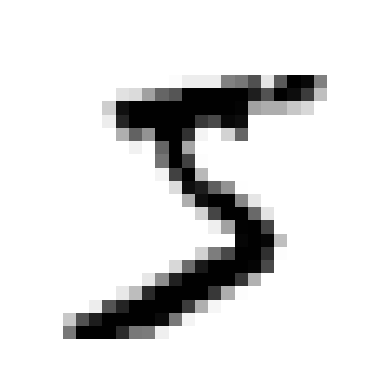

In [ ]:

# Separando nossa variavel preditora e nosso target
X = mnist['data'], 
y = mnist['target']

# Conferindo qual número a imagem representa
print('Imagen =',y[0]) 

# Pega a primeira imagem do conjunto de dados
some_digit = X.iloc[0]

# Transforma a imagem de uma linha com 784 pixels
# em uma matriz 28x28, que representa a imagem real
some_digit_image = some_digit.values.reshape(28, 28)

# Mostra a matriz como uma imagem
# cmap='binary' usa escala preto e branco
plt.imshow(some_digit_image, cmap='binary')

# Remove os eixos para visualizar apenas o dígito
plt.axis('off')    
plt.show()


In [ ]:
# Conferindo os tipo dos dados e convertendo 
y.dtype

# Convertendo para o tipo inteiro
y = y.astype(int)

In [38]:
# Seprando o treino com slice onde o treino fica com 60 mil e o resto pro treino
X_train, X_test, y_train, y_test = X.iloc[:60000], X.iloc[60000:], y[:60000], y[60000:]

In [5]:
from sklearn.linear_model import SGDClassifier

# Testando um modelo apenas com número 5
y_train_5 = (y_train == 5)
y_teste_5 = (y_train_5 == 5)

# Atribuindo um modelo 
sgd_clf = SGDClassifier(random_state=42)

# Treinando o modelo
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [6]:
# Testando no nosso exemplo acima da imagen que plotamos
sgd_clf.predict([some_digit])


c:\Users\jpdcb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [7]:
# Avalindo o modelo com Validacao cruzadas 
from sklearn.model_selection import cross_val_score, cross_val_predict

cross_val_score(sgd_clf,
                X_train,
                y_train_5,
                cv=3,
                scoring='accuracy'
)


array([0.95035, 0.96035, 0.9604 ])

In [8]:
# Criando predicts para montar uma matrix de confusão
y_train_predic = cross_val_predict(sgd_clf,
                  X_train,
                  y_train_5,
                  cv=3)


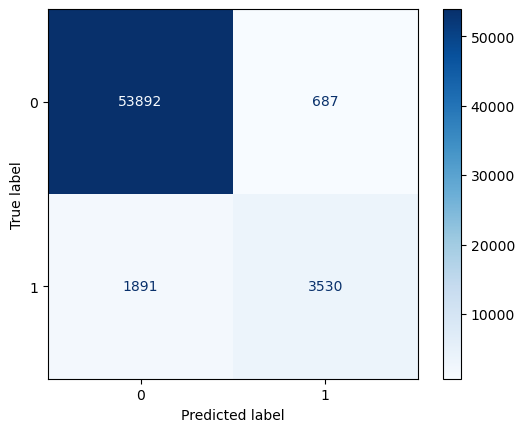

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# Cria a matriz de confusão comparando:
# valores reais vs previsões do modelo
matriz = confusion_matrix(y_train_5, y_train_predic)

# Cria o objeto responsável por desenhar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

# Desenha a matriz de confusão
disp.plot(cmap='Blues')  # cor do gráfico

plt.show()


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

# Olhando as metricas do modelo 

# Total de acerto
print('Precisao:',precision_score(y_train_5, y_train_predic))

# Quantos dos target o modelo encontrou 
print('Recall score:',recall_score(y_train_5, y_train_predic))

# Como se fosse as duas metricas acima como o equlibrios entre elas
print('F1 score', f1_score(y_train_5, y_train_predic))

Precisao: 0.8370879772350012
Recall score: 0.6511713705958311
F1 score 0.7325171197343847


In [11]:
from sklearn.metrics import precision_recall_curve, roc_curve

# pega os scores do modelo
scores = sgd_clf.decision_function(X_train)

# calcula precision, recall e thresholds
precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    scores
)

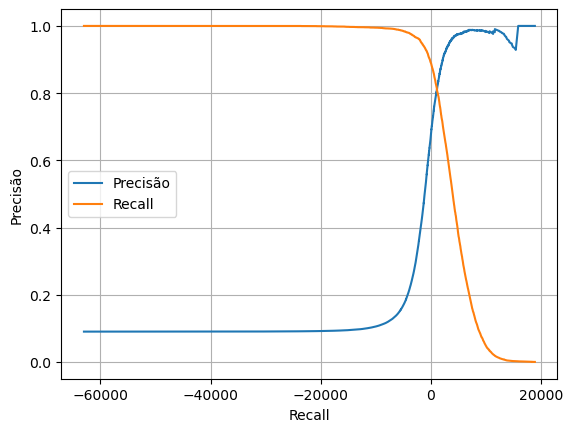

In [ ]:
# Plotando uma curva de precisao para avaliar 

plt.plot(thresholds, precisions[:-1], label="Precisão")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Pega os scores brutos do modelo
y_scores = sgd_clf.decision_function(X_train)

# Calcula precisão, recall e thresholds para vários cortes possíveis
precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

# Encontra o primeiro índice onde a precisão é maior ou igual a 90%
idx = np.argmax(precisions >= 0.90)

# Pega o threshold correspondente
threshold_90_precision = thresholds[idx]

# Aplica esse threshold para gerar as previsões finais
y_train_pred_90 = (y_scores >= threshold_90_precision)

# Conferindo metricas 
print('precisao', precision_score(y_train_5, y_train_pred_90))
print('recall', recall_score(y_train_5, y_train_pred_90))

# Separando para o plot para comparar os modelos 
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)


precisao 0.9000705384434516
recall 0.7061427780852241


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Treinando outro modelo para comparar com a curva ROC o melhor
foret_clf = RandomForestClassifier(random_state=42)

# Fazendo a validacao cruzada e criando os predict
y_score_forest = cross_val_predict(foret_clf,
                                   X_train,
                                   y_train_5,
                                   cv=3,
                                   method='predict_proba'
)

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]])

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Separando para o plot para comparar com outro modelo 
fpr_foret, tpr_foret, thresholds_forest = roc_curve(y_train_5, y_score_forest[:,1]) # Score de classe positiva 


In [20]:
# Comparando a ROC AUC dos 2 modelos 
auc1 = roc_auc_score(y_train_5, y_score_forest[:,1])
auc2 = roc_auc_score(y_train_5, y_scores)

print("Modelo 1:", auc1)
print("Modelo 2:", auc2)

Modelo 1: 0.9983436731328145
Modelo 2: 0.9709618248430906


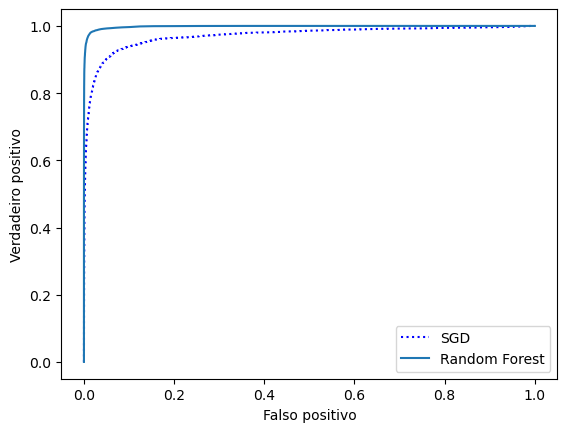

In [ ]:
# Mostrando a diferenca no gráfico 

# Plotando o primeiro modelo SGD
plt.plot(fpr, tpr, 'b:', label='SGD')

# Plotando o segundo modelo Random Forest
plt.plot(fpr_foret, tpr_foret, label='Random Forest')

# Colocando o nome do eixo X e Y
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')

# Mostrando e aparecer as labels 
plt.legend()
plt.show()

In [ ]:
# Agora Treinando o modelo para multiclasses 
foret_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Conferindo a predição da imagen de 5 que plotamos 
foret_clf.predict([some_digit])


c:\Users\jpdcb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([5])

In [ ]:
# Olhando a probabilidade para tomar a decisao da imagen que plotamos, observamos que teve 90% 
foret_clf.predict_proba([some_digit])

c:\Users\jpdcb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01]])

In [ ]:
# Agora fazendo uma validacao cruzada para avaliar se o modelo generaliza bem 
cross_val_score(foret_clf,
                X_train,
                y_train,
                cv=3,
                scoring='accuracy'
)

array([0.9646 , 0.96255, 0.9666 ])

In [ ]:
# Testando no conjunto de treino
cross_val_score(foret_clf,
                X_test,
                y_test,
                cv=3,
                scoring='accuracy'
)

array([0.92141572, 0.94119412, 0.95979598])

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scalonando os dados para ver se melhora mais ainda o modelo 

# Aplica o scaler
scaler = StandardScaler()

# Treina ele e scalona o X_train
X_train_scaler = scaler.fit_transform(X_train)

# scalona o X_teste
X_test_scaler = scaler.transform(X_test)

In [ ]:
# Avaliando os modelos apos scalonar os dados 
cross_val_score(foret_clf,
                  X_train_scaler,
                  y_train,
                  cv=3,
                  scoring='accuracy'
)

array([0.96445, 0.96255, 0.96645])

In [ ]:
cross_val_score(foret_clf,
                X_test_scaler,
                y_test,
                cv=3,
                scoring='accuracy')

array([0.9265, 0.926 , 0.947 , 0.9655, 0.97  ])

In [ ]:
# Extraindo o predicao para avaliar o modelo na matriz de confusao de multiclasse
y_train_pred = cross_val_predict(sgd_clf,
                                 X_train_scaler,
                                 y_train,
                                 cv=3,)

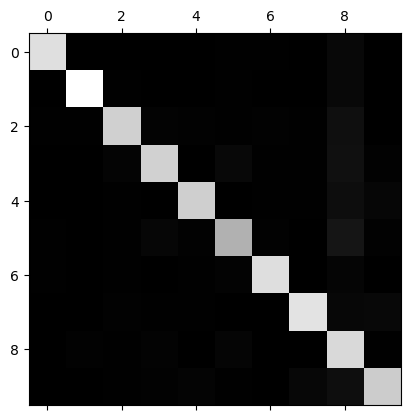

In [ ]:
# Criando a matriz para verificar se o modelo acerta bem 
conf_mx = confusion_matrix(y_train, y_train_pred)

plt.matshow(conf_mx, cmap=plt.cm.gray)

plt.show()

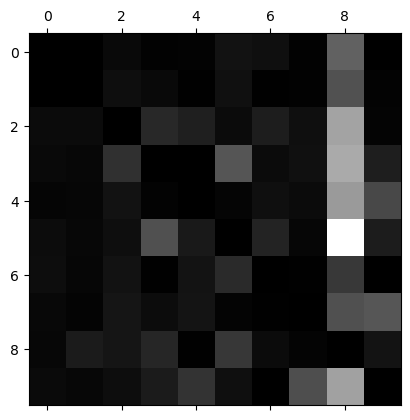

In [ ]:
# Separando os acertos para ver onde o modelo mais erra 
row_sum = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sum 


# plotando a matrix de confusao dos erros
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)

plt.show()